# General Linear Models and Least Squares

Notebook ini merangkum Chapter 11 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas **general linear model (GLM)** dan **least squares** sebagai fondasi statistik yang dibangun dari linear algebra.

Pembahasan dibuat ringkas seperti style Chapter 3: fokus pada isi chapter, rumus yang relevan, kode inti, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami general linear model sebagai framework statistik.
- Memahami mapping istilah linear algebra dan statistik.
- Menyusun design matrix untuk model linear.
- Menghitung parameter model dengan least squares.
- Memahami residual dan mengapa solusi tidak selalu exact.
- Memahami least squares dari perspektif aljabar, geometri, dan optimisasi.
- Memahami pentingnya intercept dalam model linear.
- Menggunakan QR decomposition sebagai cara yang lebih stabil untuk least squares.

## Ringkasan Chapter

Chapter ini menjelaskan bahwa statistical model adalah representasi matematis sederhana dari dunia nyata. Model statistik memiliki free parameters yang nilainya dipelajari dari data. Salah satu bentuk model statistik yang paling penting adalah general linear model atau GLM.

GLM menghubungkan predictor variables dengan dependent variable. Dalam notasi linear algebra, bentuknya mirip dengan matrix equation $Ax=b$. Dalam statistik, notasinya menjadi $X\beta=y$, dengan $X$ sebagai design matrix, $\beta$ sebagai coefficient vector, dan $y$ sebagai data atau dependent variable.

Least squares digunakan untuk mencari coefficient $\beta$ yang membuat prediksi model sedekat mungkin dengan data observed. Chapter ini menunjukkan bahwa rumus least squares dapat diturunkan dari tiga sudut pandang: aljabar melalui left-inverse, geometri melalui projection ke column space, dan optimisasi melalui minimisasi squared errors.

Chapter juga memberikan contoh sederhana menggunakan data palsu tentang jumlah kursus dan happiness. Contoh tersebut menunjukkan bahwa model tanpa intercept dapat memberikan fit yang buruk karena garis dipaksa melewati origin. Setelah intercept ditambahkan, model menjadi lebih masuk akal.

Bagian akhir membahas least squares via QR decomposition. Metode left-inverse mudah dipahami secara konsep, tetapi kurang stabil secara numerik. QR decomposition menyediakan pendekatan yang lebih stabil karena tidak perlu menghitung $X^TX$ secara eksplisit dan tidak perlu inverse penuh.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| General Linear Models | Framework statistik yang menghubungkan predictors dengan outcome. |
| Terminology | Mapping istilah linear algebra ke statistik. |
| Setting Up GLM | Membentuk model, design matrix, coefficient vector, dan data vector. |
| Solving GLMs | Least squares solution melalui left-inverse. |
| Exact Solution and Residuals | Data biasanya tidak berada tepat di column space design matrix. |
| Geometric Perspective | Least squares sebagai projection ke column space. |
| Why Least Squares Works | Least squares meminimalkan squared errors. |
| Simple Example | Model hubungan jumlah kursus dan happiness. |
| Intercept Term | Intercept memungkinkan model tidak dipaksa melewati origin. |
| Least Squares via QR | QR decomposition memberi solusi yang lebih stabil secara numerik. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    import sympy as sym
    SYMPY_AVAILABLE = True
except Exception:
    SYMPY_AVAILABLE = False

np.random.seed(2024)

## General Linear Models

General linear model atau GLM adalah model statistik yang menghubungkan independent variables atau predictors dengan dependent variable atau observed data.

Dalam linear algebra, bentuk umum matrix equation adalah:

$$
Ax=b
$$

Dalam statistik, notasi GLM ditulis sebagai:

$$
X\beta=y
$$

Keterangan:

- $X$ = design matrix
- $\beta$ = regression coefficients atau beta parameters
- $y$ = dependent variable atau observed data

Regression adalah salah satu contoh GLM.

## Terminologi Linear Algebra dan Statistik

| Linear Algebra | Statistik | Penjelasan |
|---|---|---|
| $Ax=b$ | $X\beta=y$ | Bentuk umum model linear. |
| $A$ | $X$ | Design matrix, berisi predictors/regressors. |
| $x$ | $\beta$ | Coefficient vector atau beta parameters. |
| $b$ | $y$ | Dependent variable atau outcome data. |

Chapter ini menekankan bahwa statistik menjadi lebih mudah dipahami ketika istilah-istilahnya dipetakan kembali ke konsep linear algebra.

## Setting Up a General Linear Model

Chapter memberi contoh model prediksi tinggi badan berdasarkan berat badan dan tinggi orang tua.

### Rumus Model

$$
y = \beta_0 + \beta_1w + \beta_2h + \epsilon
$$

Keterangan:

- $y$ = tinggi individu
- $w$ = berat badan
- $h$ = tinggi orang tua
- $\beta_0$ = intercept
- $\beta_1$ dan $\beta_2$ = coefficients
- $\epsilon$ = error term atau residual

Intercept adalah column berisi nilai 1. Tanpa intercept, model dipaksa melewati origin.

## Design Matrix

Contoh data pada chapter dapat ditulis dalam bentuk matrix equation:

$$
\begin{bmatrix}
1 & 70 & 177 \\
1 & 86 & 190 \\
1 & 63 & 180 \\
1 & 62 & 172
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2
\end{bmatrix}
=
\begin{bmatrix}
175 \\
181 \\
159 \\
165
\end{bmatrix}
$$

Keterangan:

- Column pertama berisi 1 untuk intercept.
- Column kedua adalah weight.
- Column ketiga adalah parents' height.
- Vector kanan adalah observed height.

In [2]:
X = np.array([
    [1, 70, 177],
    [1, 86, 190],
    [1, 63, 180],
    [1, 62, 172]
], dtype=float)

y = np.array([175, 181, 159, 165], dtype=float)

print("Design matrix X:")
print(X)

print("\nData vector y:")
print(y)

Design matrix X:
[[  1.  70. 177.]
 [  1.  86. 190.]
 [  1.  63. 180.]
 [  1.  62. 172.]]

Data vector y:
[175. 181. 159. 165.]


## Solving GLMs dengan Least Squares

Untuk menyelesaikan coefficient vector $\beta$, chapter menggunakan left-inverse dari design matrix.

### Rumus Least Squares

$$
\beta = (X^TX)^{-1}X^Ty
$$

Keterangan:

- $X$ = design matrix
- $X^T$ = transpose design matrix
- $(X^TX)^{-1}X^T$ = left-inverse dari $X$
- $y$ = observed data
- $\beta$ = estimated coefficients

Rumus ini adalah salah satu persamaan paling penting dalam applied linear algebra dan statistics.

In [3]:
X_leftinv = np.linalg.inv(X.T @ X) @ X.T
beta = X_leftinv @ y

print("Beta coefficients:")
print(beta)

Beta coefficients:
[276.85604056   1.51653185  -1.18716219]


## Is the Solution Exact?

Persamaan $X\beta=y$ hanya exact jika vector $y$ berada di column space dari $X$. Dalam data nyata, hal ini hampir tidak pernah terjadi karena data mengandung noise, sampling variability, dan model biasanya hanya penyederhanaan dari realitas.

Karena itu, GLM biasanya ditulis dengan residual:

$$
X\beta + \epsilon = y
$$

atau:

$$
\epsilon = X\beta - y
$$

Keterangan:

- $\epsilon$ = residual atau error term
- $X\beta$ = model-predicted data
- $y$ = observed data

Tujuan model adalah mencari kombinasi linear columns pada $X$ yang sedekat mungkin dengan $y$.

In [4]:
y_hat = X @ beta
residuals = y_hat - y

print("Predicted y:")
print(np.round(y_hat, 3))

print("\nResiduals:")
print(np.round(residuals, 3))

print("\nSSE:", np.sum(residuals**2))

Predicted y:
[172.886 181.717 158.708 166.689]

Residuals:
[-2.114  0.717 -0.292  1.689]

SSE: 7.923062586200471


## Geometric Perspective on Least Squares

Secara geometri, columns dari design matrix $X$ membentuk column space. Data vector $y$ biasanya tidak berada tepat di column space tersebut. Least squares mencari titik di column space $X$ yang paling dekat dengan $y$.

Jarak terpendek terjadi ketika residual orthogonal terhadap column space:

$$
X^T\epsilon=0
$$

Karena:

$$
\epsilon = y - X\beta
$$

maka:

$$
X^T(y-X\beta)=0
$$

Sehingga:

$$
X^TX\beta = X^Ty
$$

dan akhirnya:

$$
\beta = (X^TX)^{-1}X^Ty
$$

## Why Does Least Squares Work?

Least squares disebut demikian karena metode ini mencari coefficients yang meminimalkan squared errors antara predicted data dan observed data.

Residual vector:

$$
\epsilon = X\beta - y
$$

Objective function:

$$
\min_{\beta}\|X\beta-y\|^2
$$

Keterangan:

- $\|X\beta-y\|^2$ = squared norm dari residuals
- Squaring membuat error positif dan negatif sama-sama berkontribusi positif
- Coefficients dipilih agar total squared error minimum

Dengan derivasi calculus, objective tersebut menghasilkan rumus least squares yang sama:

$$
\beta = (X^TX)^{-1}X^Ty
$$

## GLM in a Simple Example

Chapter memberi contoh data palsu tentang jumlah online courses yang diambil dan self-reported life happiness.

Pada contoh pertama, design matrix hanya berisi satu predictor, yaitu jumlah kursus. Modelnya:

$$
y = \beta x
$$

Karena tidak ada intercept, garis prediksi dipaksa melewati origin.

In [5]:
numcourses = np.array([4, 12, 3, 14, 13, 12, 9, 11, 7, 13,
                       11, 9, 2, 5, 7, 10, 0, 9, 7, 14], dtype=float)

happiness = np.array([25, 54, 21, 80, 68, 84, 62, 57, 40, 60,
                      64, 45, 38, 51, 52, 58, 21, 75, 70, 70], dtype=float)

X_no_intercept = np.array(numcourses, ndmin=2).T

beta_no_intercept = np.linalg.inv(X_no_intercept.T @ X_no_intercept) @ X_no_intercept.T @ happiness
pred_no_intercept = X_no_intercept @ beta_no_intercept
sse_no_intercept = np.sum((pred_no_intercept - happiness)**2)

print("Beta without intercept:", beta_no_intercept)
print("SSE without intercept:", sse_no_intercept)

Beta without intercept: [5.87416851]
SSE without intercept: 4206.436252771618


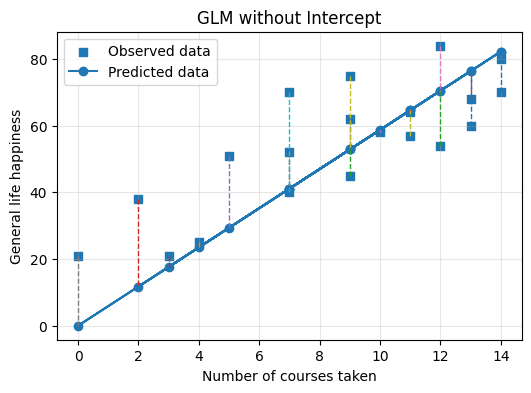

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(numcourses, happiness, marker="s", label="Observed data")
plt.plot(numcourses, pred_no_intercept, "o-", label="Predicted data")
for xval, yobs, ypred in zip(numcourses, happiness, pred_no_intercept):
    plt.plot([xval, xval], [yobs, ypred], linestyle="--", linewidth=1)
plt.xlabel("Number of courses taken")
plt.ylabel("General life happiness")
plt.title("GLM without Intercept")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Intercept Term

Tanpa intercept, model berbentuk:

$$
y=mx
$$

Artinya ketika $x=0$, prediksi $y$ harus 0. Pada banyak kasus, asumsi ini tidak masuk akal.

Dengan intercept, model menjadi:

$$
y=mx+b
$$

Dalam design matrix, intercept ditambahkan sebagai column berisi 1:

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
$$

Intercept menunjukkan expected value dari outcome ketika predictor bernilai 0.

In [7]:
X_intercept = np.hstack((
    np.ones((len(numcourses), 1)),
    np.array(numcourses, ndmin=2).T
))

beta_intercept = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ happiness
pred_intercept = X_intercept @ beta_intercept
sse_intercept = np.sum((pred_intercept - happiness)**2)

print("Beta with intercept:", beta_intercept)
print("SSE with intercept:", sse_intercept)

Beta with intercept: [23.50615764  3.63300493]
SSE with intercept: 2216.8041871921178


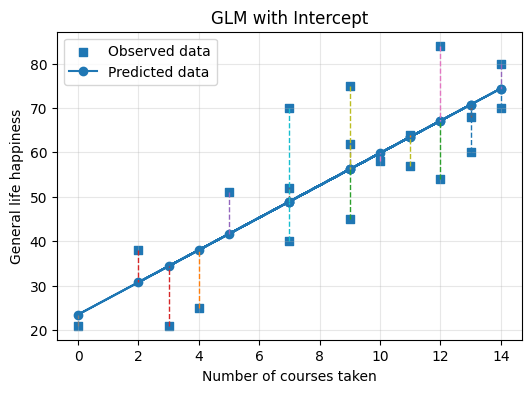

In [8]:
plt.figure(figsize=(6, 4))
plt.scatter(numcourses, happiness, marker="s", label="Observed data")
plt.plot(numcourses, pred_intercept, "o-", label="Predicted data")
for xval, yobs, ypred in zip(numcourses, happiness, pred_intercept):
    plt.plot([xval, xval], [yobs, ypred], linestyle="--", linewidth=1)
plt.xlabel("Number of courses taken")
plt.ylabel("General life happiness")
plt.title("GLM with Intercept")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Analisis Intercept

Pada contoh chapter, model dengan intercept memiliki fit yang lebih baik karena garis tidak lagi dipaksa melewati origin. Secara statistik, intercept menunjukkan nilai prediksi ketika predictor bernilai nol.

Perbandingan sederhananya:

| Model | Bentuk | Keterangan |
|---|---|---|
| Tanpa intercept | $y=mx$ | Garis dipaksa melewati origin. |
| Dengan intercept | $y=mx+b$ | Garis dapat memotong y-axis di nilai bebas. |

Dalam banyak model statistik, intercept sangat penting karena memberi fleksibilitas tambahan pada model.

## Least Squares via QR

Metode left-inverse mudah dipahami, tetapi kurang stabil secara numerik karena melibatkan $X^TX$ dan inverse. QR decomposition menyediakan cara yang lebih stabil.

Mulai dari:

$$
X\beta=y
$$

Jika:

$$
X=QR
$$

maka:

$$
QR\beta=y
$$

Premultiply dengan $Q^T$:

$$
R\beta=Q^Ty
$$

Sehingga:

$$
\beta=R^{-1}Q^Ty
$$

Pada implementasi numerik, $R$ tidak selalu perlu diinvers secara eksplisit karena upper-triangular system dapat diselesaikan dengan back substitution.

In [9]:
Q, R = np.linalg.qr(X_intercept)

beta_qr = np.linalg.inv(R) @ Q.T @ happiness

print("Beta from left-inverse:")
print(np.round(beta_intercept, 3))

print("\nBeta from QR:")
print(np.round(beta_qr, 3))

Beta from left-inverse:
[23.506  3.633]

Beta from QR:
[23.506  3.633]


## QR dan RREF untuk Least Squares

Chapter juga menunjukkan bahwa solusi least squares via QR dapat ditulis sebagai augmented matrix:

$$
\begin{bmatrix}
R & Q^Ty
\end{bmatrix}
$$

Kemudian Gauss-Jordan elimination atau RREF digunakan untuk mendapatkan $\beta$.

In [10]:
if SYMPY_AVAILABLE:
    Qty = Q.T @ happiness
    R_aug = np.hstack((R, Qty.reshape(-1, 1)))

    rref_R_aug = sym.Matrix(R_aug).rref()[0]

    print("Matrix R:")
    print(np.round(R, 3))

    print("\nMatrix R | Q'y:")
    print(np.round(R_aug, 3))

    print("\nRREF(R | Q'y):")
    print(rref_R_aug)
else:
    print("SymPy tidak tersedia di environment ini.")

SymPy tidak tersedia di environment ini.


## Residuals Orthogonal terhadap Predicted Data

Chapter exercises menekankan bahwa residuals orthogonal terhadap predicted data dan juga terhadap column space dari design matrix.

Secara konsep:

$$
X^T\epsilon=0
$$

Karena predicted data adalah linear combination dari columns $X$, residuals juga orthogonal terhadap predicted values.

In [11]:
residuals = pred_intercept - happiness

dot_res_pred = np.dot(residuals, pred_intercept)
corr_res_pred = np.corrcoef(residuals, pred_intercept)[0, 1]

print("Dot product residuals and predicted:", dot_res_pred)
print("Correlation residuals and predicted:", corr_res_pred)

Dot product residuals and predicted: 4.774847184307873e-12
Correlation residuals and predicted: -3.29843599454514e-16


## Pengaruh Outlier

Chapter exercises juga menunjukkan bahwa outlier dapat memengaruhi hasil least squares. Outlier dengan nilai outcome yang sama dapat memiliki efek berbeda tergantung posisi predictor-nya. Perbedaan pengaruh ini disebut leverage.

Contoh berikut menampilkan efek outlier pada data pertama dan data terakhir.

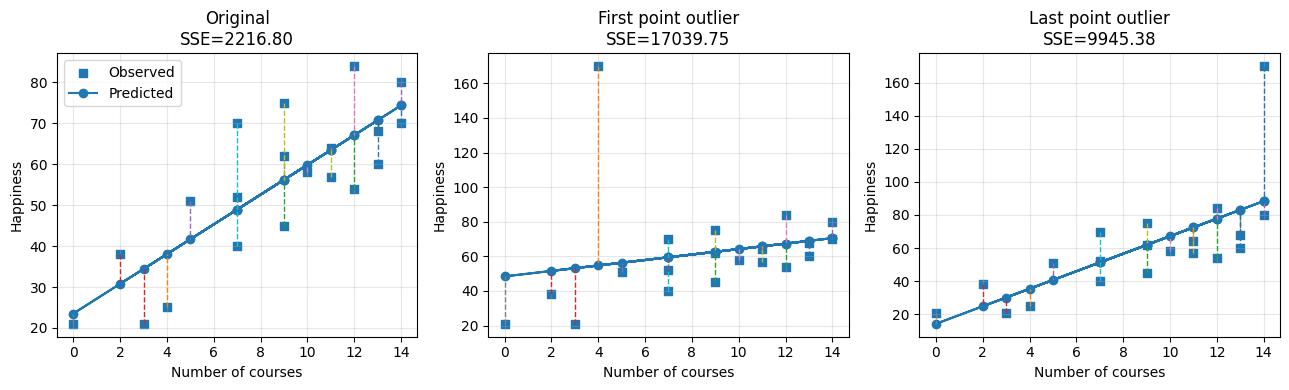

In [12]:
def fit_and_predict(ydata):
    beta = np.linalg.inv(X_intercept.T @ X_intercept) @ X_intercept.T @ ydata
    pred = X_intercept @ beta
    sse = np.sum((pred - ydata)**2)
    return beta, pred, sse

y_original = happiness.copy()
y_outlier_first = happiness.copy()
y_outlier_last = happiness.copy()

y_outlier_first[0] = 170
y_outlier_last[-1] = 170

cases = [
    ("Original", y_original),
    ("First point outlier", y_outlier_first),
    ("Last point outlier", y_outlier_last)
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (title, ycase) in zip(axes, cases):
    beta, pred, sse = fit_and_predict(ycase)
    ax.scatter(numcourses, ycase, marker="s", label="Observed")
    ax.plot(numcourses, pred, "o-", label="Predicted")
    for xval, yobs, ypred in zip(numcourses, ycase, pred):
        ax.plot([xval, xval], [yobs, ypred], linestyle="--", linewidth=1)
    ax.set_title(f"{title}\nSSE={sse:.2f}")
    ax.set_xlabel("Number of courses")
    ax.set_ylabel("Happiness")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Statistical model | Representasi matematis sederhana dari fenomena dunia nyata. |
| GLM | Framework model linear yang menghubungkan predictors dan outcome. |
| Design matrix | Matrix $X$ yang columns-nya berisi predictors. |
| Beta coefficients | Parameters model yang dipelajari dari data. |
| Dependent variable | Data outcome yang diprediksi oleh model. |
| Least squares | Metode mencari coefficients yang meminimalkan squared errors. |
| Residual | Selisih antara predicted data dan observed data. |
| Column space | Ruang semua linear combinations dari predictors. |
| Intercept | Column 1s yang memungkinkan model tidak melewati origin. |
| QR least squares | Solusi least squares yang lebih stabil secara numerik. |
| Outlier leverage | Pengaruh outlier bergantung pada posisi predictor-nya. |

## Kesimpulan Chapter

Chapter ini memperkenalkan general linear model sebagai framework statistik yang dibangun langsung dari linear algebra. Bentuk $X\beta=y$ adalah versi statistik dari matrix equation yang sudah dipelajari pada chapter sebelumnya.

Least squares mencari coefficient vector $\beta$ yang membuat model-predicted data sedekat mungkin dengan observed data. Rumus least squares dapat diturunkan melalui left-inverse, geometric projection, dan minimisasi squared errors.

Residuals menjadi bagian penting karena data nyata hampir tidak pernah berada tepat di column space design matrix. Least squares mencari projection terbaik dari data ke column space tersebut, sehingga residuals menjadi orthogonal terhadap design matrix.

Contoh sederhana pada chapter menunjukkan pentingnya intercept. Tanpa intercept, model dipaksa melewati origin dan dapat menghasilkan fit yang kurang baik. Dengan intercept, model menjadi lebih fleksibel dan lebih sesuai dengan data.

Terakhir, chapter menjelaskan bahwa QR decomposition dapat digunakan untuk menyelesaikan least squares secara lebih stabil dibanding left-inverse eksplisit. Konsep ini menjadi jembatan menuju penerapan least squares pada data nyata di chapter berikutnya.